# Funciones de distribucion de probabilidades

## Distribucion Uniforme

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
a = 1
b = 100
n = 1000000

data = np.random.uniform(a, b, n)

(array([ 99935., 100045., 100063.,  99817., 100230.,  99804., 100255.,
        100227.,  99513., 100111.]),
 array([ 1.0000142 , 10.90000962, 20.80000504, 30.70000046, 40.59999588,
        50.49999129, 60.39998671, 70.29998213, 80.19997755, 90.09997297,
        99.99996839]),
 <BarContainer object of 10 artists>)

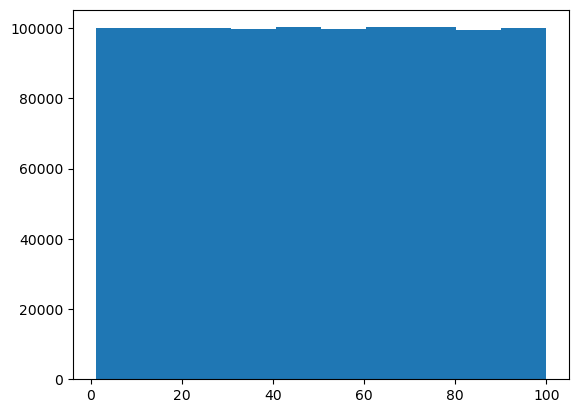

In [14]:
plt.hist(data)

## Distribucion Normal

In [19]:
data = np.random.randn(1000000)

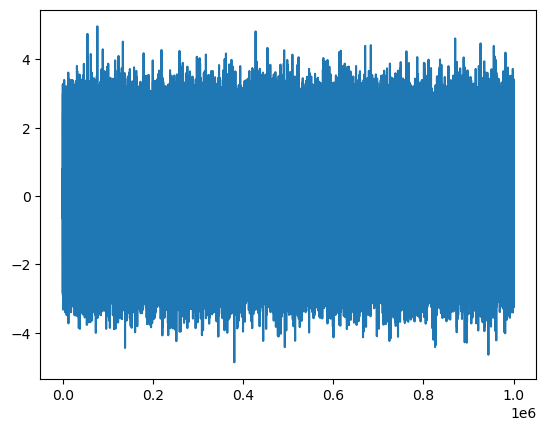

In [22]:
x = range(1, 1000001)

plt.plot(x, data)

(array([5.00000e+01, 1.81200e+03, 2.60270e+04, 1.47873e+05, 3.44799e+05,
        3.29569e+05, 1.28332e+05, 2.02250e+04, 1.27400e+03, 3.90000e+01]),
 array([-4.86628406, -3.88250701, -2.89872996, -1.91495291, -0.93117586,
         0.05260119,  1.03637824,  2.02015529,  3.00393234,  3.98770939,
         4.97148644]),
 <BarContainer object of 10 artists>)

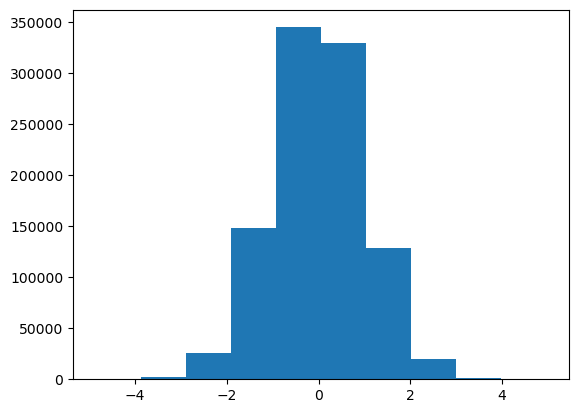

In [23]:
plt.hist(data)

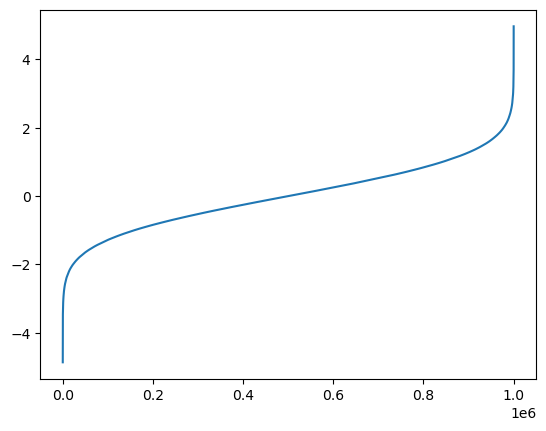

In [24]:
# Output => Funcion de distribucion acumulada
plt.plot(x, sorted(data))

(array([   6.,   46.,  315., 1183., 2496., 2959., 1984.,  792.,  193.,
          26.]),
 array([-4.79260393, -2.86668531, -0.94076669,  0.98515193,  2.91107055,
         4.83698916,  6.76290778,  8.6888264 , 10.61474502, 12.54066364,
        14.46658226]),
 <BarContainer object of 10 artists>)

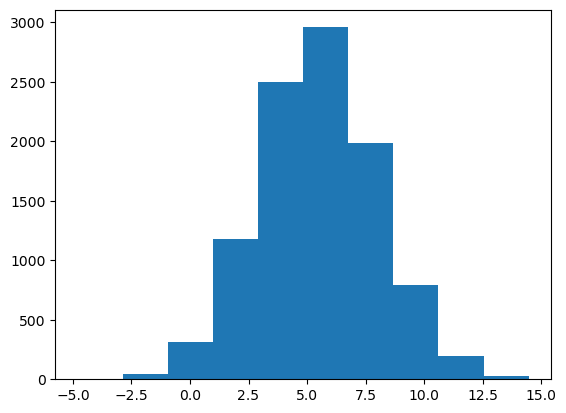

In [26]:
mu = 5.5
sd = 2.5
Z_10000 = np.random.randn(10000)
"""
    Teorema central del limite (tipificar)
    Z = (X - mu) / sd => N(0,1), X = mu + sd * Z
"""
data = mu + sd * Z_10000 
plt.hist(data)

In [27]:
data = np.random.randn(2, 4)
data

array([[-1.09585504, -1.28675676,  0.58124471, -1.77464985],
       [ 1.36175944,  1.00426499,  0.20624328,  0.01642939]])

## La simulacion de Monte Carlo

* Generamos dos numeros aleatorios uniformes (x e y) entre 0 y 1 en total 1000000 veces
* Calculamos x^2 + y^2
  * Si valor es inferior a 1 -> Estamos dentro del circulo
  * Si el valor es superior a 1 -> Estamos fuera del circulo
* Calculamos el numero total de veces que estan dentro del circulo y lo dividimos entre el numero total de intentos para obtener una aproximacion de la probabilidad de caer dentro del circulo.
* Usamos dicha probabilidad para aproximar el valor de pi
* Repetimos el experimento un numero suficiente de veces (por ejemplo 100), para obtener diferentes aproximaciones de pi
* Calculamos el promedio de los 100 exprerimentosanteriores para dar un valor final de pi 

In [32]:
def pi_montecarlo(n, n_exp):
    pi_avg = 0
    pi_value_list = []
    for i in range(n_exp):
        value = 0
        x = np.random.uniform(0, 1, n).tolist()
        y = np.random.uniform(0, 1, n).tolist()
        for j in range(n):
            z = np.sqrt(x[j] * x[j] + y[j] * y[j])
            if z <= 1:
                value += 1
        float_value = float(value)
        pi_value = float_value * 4 / n
        pi_value_list.append(pi_value)
        pi_avg += pi_value
    
    pi = pi_avg/n_exp
    fig = plt.plot(pi_value_list)
    return (pi, fig)

In [ ]:
pi_montecarlo(1000000, 200)